In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvY2hhbmNlL3F1YXJ0by1sYWIvdGhlb3J5L09TRg=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/importlib/_bootstrap.py": 1781600678.0429904, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/importlib/_bootstrap_external.py": 1781600678.0469904, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/zipimport.py": 1781600678.926988, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/codecs.py": 1781600677.3309925, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/encodings/aliases.py": 1781600677.3909922, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/encodings/__init__.py": 1781600677.3909922, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/encodings/utf_8.py": 1781600677.414992, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/abc.py": 1781600677.29899

In [2]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Qubit, Clbit

class DualCircuitConverter:
    def __init__(self, original_circuit: QuantumCircuit, 
                 input_state: str = None, 
                 output_pauli: str = None):
        self.orig_qc = original_circuit
        self.n_qubits = original_circuit.num_qubits

        self.input_state_str = input_state
        self.output_pauli_str = output_pauli

        self.q_map = {q: i for i, q in enumerate(original_circuit.qubits)}
        
        self.dual_qc = None
        self._build_dual_circuit()

    def _build_dual_circuit(self):
        reg_a = QuantumRegister(self.n_qubits, 'a')
        reg_b = QuantumRegister(self.n_qubits, 'b')
        registers = [reg_a, reg_b]
        if self.input_state_str:
            creg = ClassicalRegister(2 * self.n_qubits, 'meas')
            registers.append(creg)
        
        self.dual_qc = QuantumCircuit(*registers)
        
        if self.output_pauli_str:
            if len(self.output_pauli_str) != self.n_qubits:
                raise ValueError("Output Pauli string length must match num_qubits.")

            for i, p_char in enumerate(self.output_pauli_str):
                p_char = p_char.upper()
                if p_char == 'Z':   # |0>_a |1>_b
                    self.dual_qc.x(reg_b[i])
                elif p_char == 'X': # |1>_a |0>_b
                    self.dual_qc.x(reg_a[i])
                elif p_char == 'Y': # |1>_a |1>_b
                    self.dual_qc.x(reg_a[i])
                    self.dual_qc.x(reg_b[i])
            
            self.dual_qc.barrier(label='Dual Input')

        for instruction in reversed(self.orig_qc.data):
            op_name = instruction.operation.name
            qubits = instruction.qubits
            
            indices = [self.q_map[q] for q in qubits]
            
            if op_name == 'h':
                # H -> CZ_ab * SWAP_ab
                idx = indices[0]
                self.dual_qc.swap(reg_a[idx], reg_b[idx])
                self.dual_qc.cz(reg_a[idx], reg_b[idx])
                
            elif op_name == 's':
                # S -> CZ_ab * CNOT_ab
                idx = indices[0]
                self.dual_qc.cx(reg_a[idx], reg_b[idx])
                self.dual_qc.cz(reg_a[idx], reg_b[idx])
                
            elif op_name == 't':
                # T -> Z_b * CH_ab
                idx = indices[0]
                self.dual_qc.ch(reg_a[idx], reg_b[idx]) 
                self.dual_qc.cz(reg_a[idx], reg_b[idx])
                
            elif op_name == 'cx':
                # CNOT -> CNOT_a * CNOT_b (reverse direction)
                c_idx, t_idx = indices[0], indices[1]
                self.dual_qc.ccz(reg_a[c_idx], reg_b[t_idx], reg_a[t_idx])
                self.dual_qc.ccz(reg_a[c_idx], reg_b[t_idx], reg_b[c_idx])
                self.dual_qc.cz(reg_a[c_idx], reg_b[t_idx])
                self.dual_qc.cx(reg_a[c_idx], reg_a[t_idx]) # a: control -> target
                self.dual_qc.cx(reg_b[t_idx], reg_b[c_idx]) # b: target -> control

                
            elif op_name == 'barrier':
                mapped_qubits = []
                for idx in indices:
                    mapped_qubits.append(reg_a[idx])
                    mapped_qubits.append(reg_b[idx])
                self.dual_qc.barrier(*mapped_qubits)

        if self.input_state_str:
            self.dual_qc.barrier(label='Dual Output')
            if len(self.input_state_str) != self.n_qubits:
                raise ValueError("Input state string length must match num_qubits.")
            for i, s_char in enumerate(self.input_state_str):
                if s_char == '0':
                    self.dual_qc.h(reg_b[i])
                elif s_char == '1':

                    self.dual_qc.h(reg_b[i]) 
            
            self.dual_qc.measure(reg_a, creg[:self.n_qubits])
            self.dual_qc.measure(reg_b, creg[self.n_qubits:])

    def draw_comparison(self, scale=0.5):

        fig, axes = plt.subplots(2, 1, figsize=(12 * scale, 10 * scale))
        self.orig_qc.draw('mpl', ax=axes[0], style='iqp')
        
        in_txt = f"|{self.input_state_str}>" if self.input_state_str else "State"
        out_txt = f"<{self.output_pauli_str}>" if self.output_pauli_str else "Pauli"
        axes[0].set_title(f"Original Circuit: Input {in_txt} $\\rightarrow$ Measure {out_txt}", fontsize=13)
        axes[0].set_ylabel("Time $\\rightarrow$")

        self.dual_qc.draw('mpl', ax=axes[1], style='iqp', fold=-1)
        
        dual_in_txt = f"State({self.output_pauli_str})" if self.output_pauli_str else "Input"
        dual_out_txt = f"Project({self.input_state_str})" if self.input_state_str else "Output"
        axes[1].set_title(f"Dual Circuit: Input {dual_in_txt} $\\rightarrow$ Measure {dual_out_txt}", fontsize=13)
        axes[1].set_ylabel("Time $\\leftarrow$ (Reversed)")
        
        plt.tight_layout()
        plt.show()
        plt.close(fig)

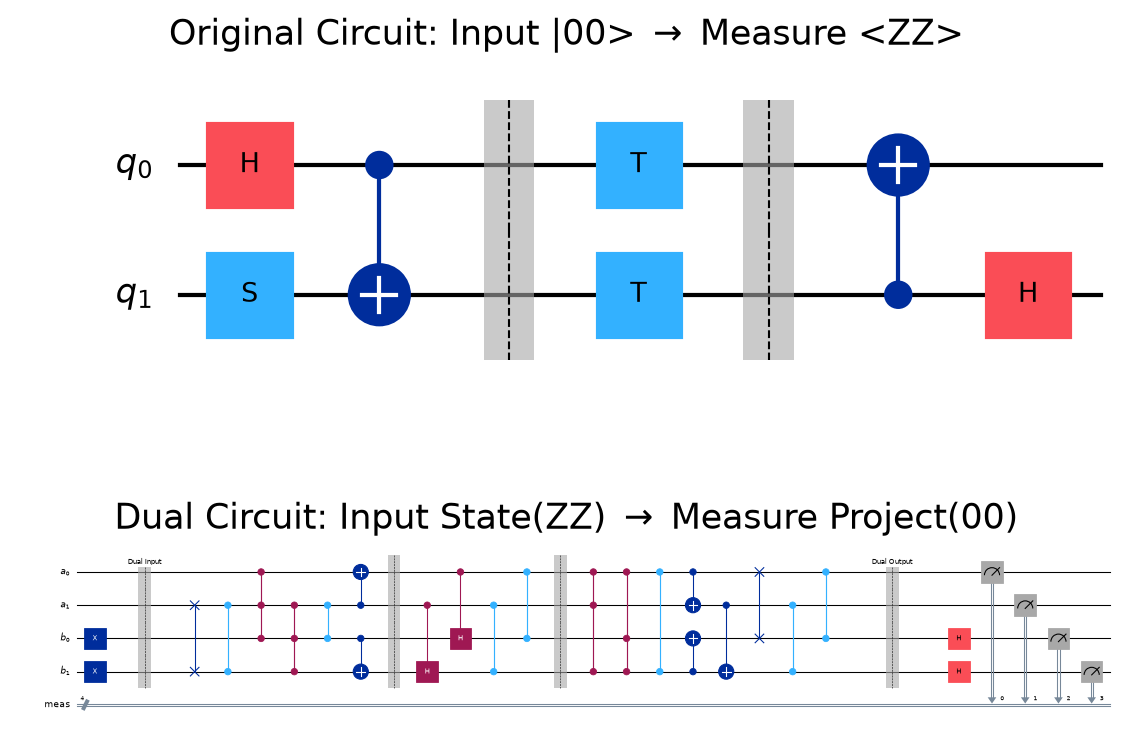

 ZZ : original 0.0000+0.0000j vs dual -0.0000+0.0000j
----------------------------------------------------------------------------------------------------
 IZ : original 0.0000+0.0000j vs dual 0.0000+0.0000j
----------------------------------------------------------------------------------------------------
 IX : original 0.0000+0.0000j vs dual 0.0000+0.0000j
----------------------------------------------------------------------------------------------------
 IY : original -1.0000+0.0000j vs dual -1.0000+0.0000j
----------------------------------------------------------------------------------------------------
 ZX : original 0.0000+0.0000j vs dual 0.0000+0.0000j
----------------------------------------------------------------------------------------------------
 ZY : original -1.0000+0.0000j vs dual -1.0000+0.0000j
----------------------------------------------------------------------------------------------------
 XY : original 0.0000+0.0000j vs dual 0.0000+0.0000j
------------------

In [3]:
from qiskit.quantum_info import Statevector, SparsePauliOp
qc = QuantumCircuit(2)
# Bell State
qc.h(0)
qc.s(1)
qc.cx(0, 1)
qc.barrier() 
# Phase gates
qc.t(0)      # S on q0
qc.t(1)      # T on q1
qc.barrier() 
# Interference
qc.cx(1, 0)
qc.h(1)
Paulis = ["ZZ","IZ","IX","IY","ZX","ZY","XY","XX","YY","YZ","XZ"]
state_orig = Statevector.from_instruction(qc)
for pauli in Paulis:
    converter = DualCircuitConverter(qc, input_state="00", output_pauli = pauli)
    if pauli == "ZZ":
        converter.draw_comparison()
    converter.dual_qc.remove_final_measurements()
    state = Statevector(converter.dual_qc)
    amplitude_00 =  state.data[0]
    n = converter.n_qubits
    dual_value = (2**(n/2)) * amplitude_00
    expectation_value = state_orig.expectation_value(SparsePauliOp(pauli[::-1]))
    print(f" {pauli} : original {expectation_value:.4f} vs dual {dual_value:.4f}")
    print("-"*100)

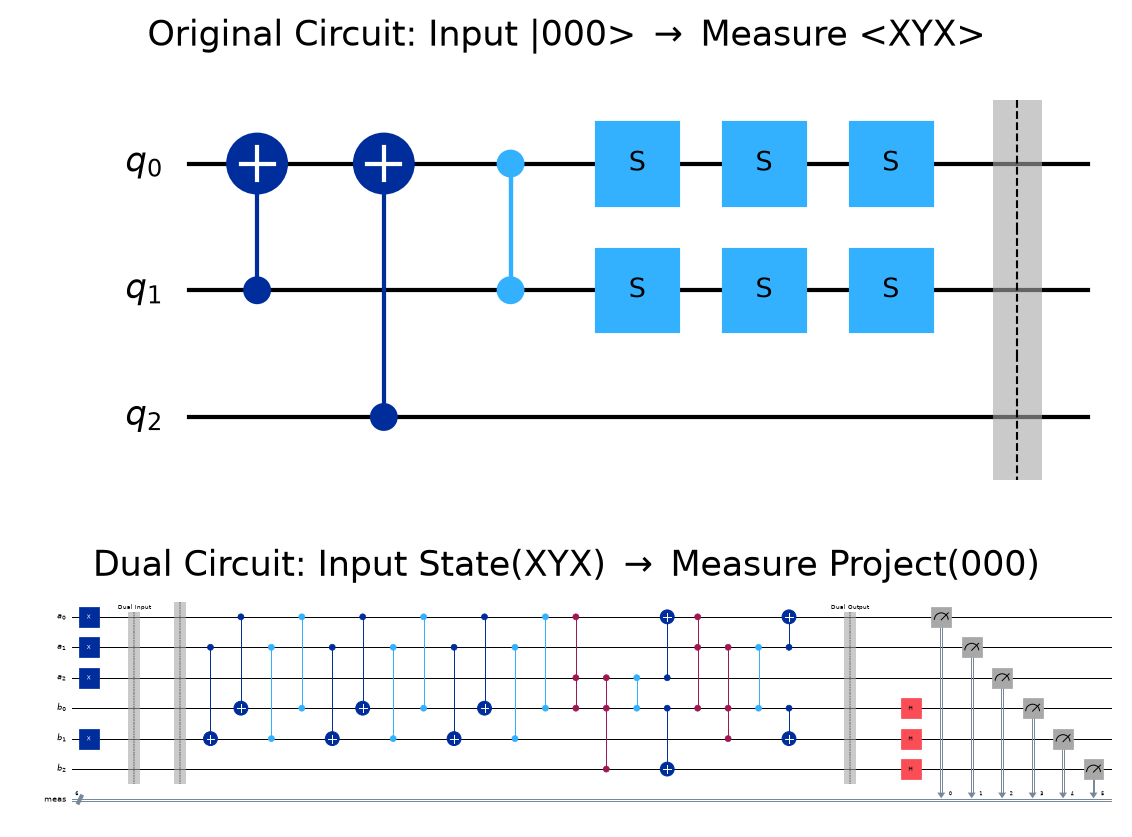

 XYX : original 0.0000+0.0000j vs dual 0.0000+0.0000j
----------------------------------------------------------------------------------------------------
 IZZ : original 1.0000+0.0000j vs dual 1.0000+0.0000j
----------------------------------------------------------------------------------------------------
 IXZ : original 0.0000+0.0000j vs dual 0.0000+0.0000j
----------------------------------------------------------------------------------------------------
 IYZ : original 0.0000+0.0000j vs dual 0.0000+0.0000j
----------------------------------------------------------------------------------------------------
 ZXZ : original 0.0000+0.0000j vs dual 0.0000+0.0000j
----------------------------------------------------------------------------------------------------
 ZYZ : original 0.0000+0.0000j vs dual 0.0000+0.0000j
----------------------------------------------------------------------------------------------------
 XZZ : original 0.0000+0.0000j vs dual 0.0000+0.0000j
----------------

In [4]:
qc = QuantumCircuit(3)
qc.cx(1, 0)
qc.cx(2, 0)
qc.cz(0, 1)
qc.s(0)
qc.s(0)
qc.s(0)
qc.s(1)
qc.s(1)
qc.s(1)
qc.barrier() 
Paulis = ["XYX","IZZ","IXZ","IYZ","ZXZ","ZYZ","XZZ","YZZ","ZIZ","ZIZ","ZIX","ZIY","ZXZ","ZYZ","XZZ","YZZ"]
state_orig = Statevector.from_instruction(qc)
for pauli in Paulis:
    converter = DualCircuitConverter(qc, input_state="000", output_pauli = pauli)
    if pauli == "XYX":
        converter.draw_comparison()
    converter.dual_qc.remove_final_measurements()
    state = Statevector(converter.dual_qc)
    amplitude_00 =  state.data[0]
    n = converter.n_qubits
    dual_value = (2**(n/2)) * amplitude_00
    expectation_value = state_orig.expectation_value(SparsePauliOp(pauli[::-1]))
    print(f" {pauli} : original {expectation_value:.4f} vs dual {dual_value:.4f}")
    print("-"*100)
